## Работа Максимовой Алины 6133-010402D
Импортируем необходимые библиотеки:

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
import pandas as pd
import warnings

Проверка подключения к GPU:

In [ ]:
# Проверка GPU
assert cuda.is_available(), "CUDA GPU не найдено"

Сложение вектора на CPU:

In [ ]:
def cpu_sum(vector):
    result = 0.0
    for i in range(len(vector)):
        result += vector[i]
    return result

Сложение вектора на GPU:

In [ ]:
@cuda.jit
def gpu_sum_kernel(vector, result):
    temp = cuda.shared.array(512, dtype=np.float32)
    idx = cuda.grid(1)

    if idx < vector.size:
        temp[cuda.threadIdx.x] = vector[idx]
    else:
        temp[cuda.threadIdx.x] = 0.0

    cuda.syncthreads()

    i = cuda.blockDim.x // 2
    while i > 0:
        if cuda.threadIdx.x < i:
            temp[cuda.threadIdx.x] += temp[cuda.threadIdx.x + i]
        cuda.syncthreads()
        i //= 2

    if cuda.threadIdx.x == 0:
        cuda.atomic.add(result, 0, temp[0])

def gpu_sum(vector):
    result = np.zeros(1, dtype=np.float32)
    d_result = cuda.to_device(result)
    d_vector = cuda.to_device(vector)

    threads_per_block = 512
    blocks_per_grid = (vector.size + (threads_per_block - 1)) // threads_per_block
    gpu_sum_kernel[blocks_per_grid, threads_per_block](d_vector, d_result)
    cuda.synchronize()
    return d_result.copy_to_host()[0]

Измерение времени:

In [ ]:
def measure_time(vector_size):
    vector = np.random.rand(vector_size).astype(np.float32)

    warmup_vector = np.random.rand(1000).astype(np.float32)  # Маленький вектор для прогрева
    for _ in range(3):  # 3 прогревочных запуска
        _ = gpu_sum(warmup_vector)

    start_time = time.time()
    cpu_result = cpu_sum(vector)
    cpu_time = time.time() - start_time

    start_time = time.time()
    gpu_result = gpu_sum(vector)
    gpu_time = time.time() - start_time

    speedup = cpu_time / gpu_time
    return cpu_time, gpu_time, speedup

Эксперимент:

In [ ]:
vector_sizes = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]
results = {"Размер вектора": [], "Время на CPU (с)": [], "Время на GPU (с)": [], "Ускорение": []}

for size in vector_sizes:
    cpu_time, gpu_time, speedup = measure_time(size)
    results["Размер вектора"].append(size)
    results["Время на CPU (с)"].append(cpu_time)
    results["Время на GPU (с)"].append(gpu_time)
    results["Ускорение"].append(speedup)

df_results = pd.DataFrame(results)
print(df_results)

   Размер вектора  Время на CPU (с)  Время на GPU (с)  Ускорение
0            1000          0.000576          0.002773   0.207549
1            5000          0.001486          0.000896   1.658420
2           10000          0.002933          0.001024   2.863827
3           50000          0.014652          0.000942  15.557722
4          100000          0.022270          0.000887  25.096185
5          500000          0.071152          0.001013  70.268896
6         1000000          0.143174          0.001859  77.018597


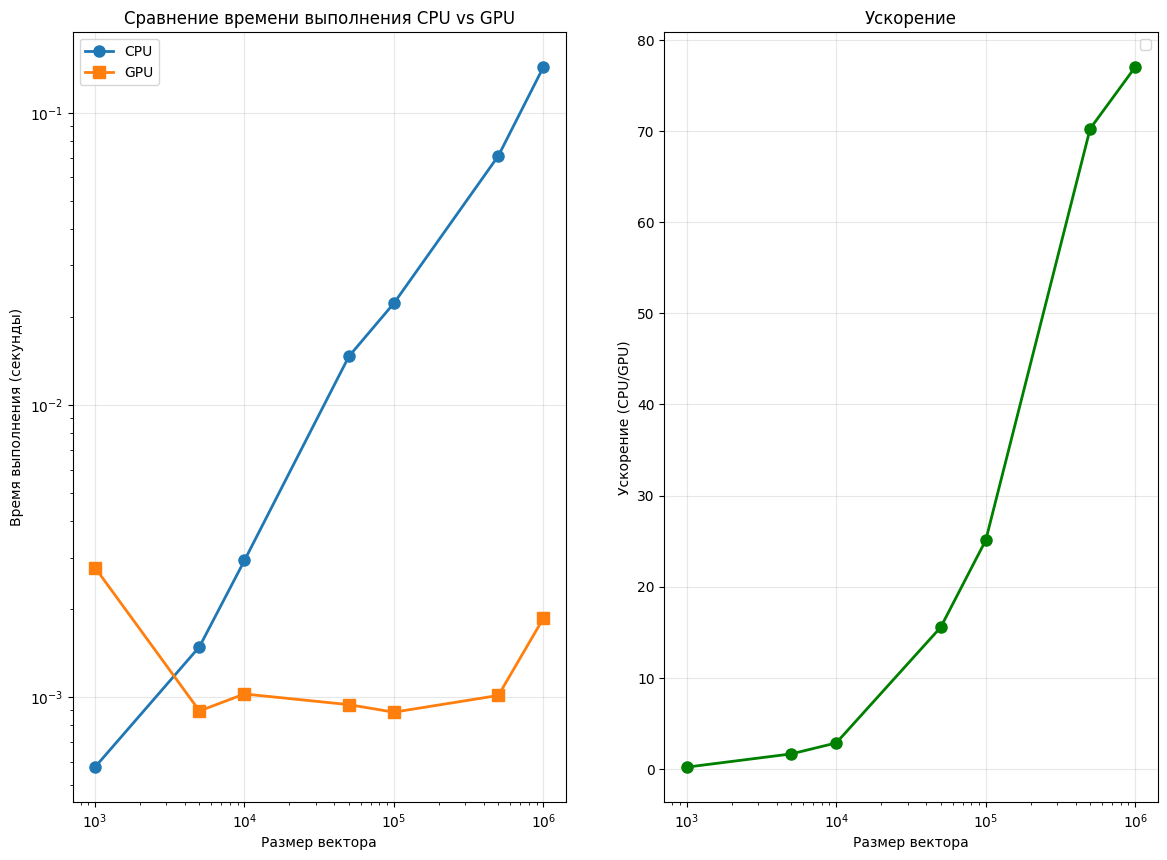

In [ ]:
# Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))

ax1.plot(vector_sizes, results["Время на CPU (с)"], 'o-', label='CPU', linewidth=2, markersize=8)
ax1.plot(vector_sizes, results["Время на GPU (с)"], 's-', label='GPU', linewidth=2, markersize=8)
ax1.set_xlabel('Размер вектора')
ax1.set_ylabel('Время выполнения (секунды)')
ax1.set_title('Сравнение времени выполнения CPU vs GPU')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# 2. Ускорение
ax2.plot(vector_sizes, results["Ускорение"], 'o-', color='green', linewidth=2, markersize=8)
ax2.set_xlabel('Размер вектора')
ax2.set_ylabel('Ускорение (CPU/GPU)')
ax2.set_title('Ускорение')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
